In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Titanic dataset ko online source se load karte hain
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Pehle check karte hain ki kis column me kitni missing values hain
print("Missing values preprocessing se pehle:\n", df.isnull().sum())
print("-" * 50)

# 1. Age ke missing values ko Median se fill karo
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Embarked ke missing values ko Mode (most frequent value) se fill karo
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Check karte hain ki ab koi missing value bachi to nahi
print("Missing values preprocessing ke baad:\n", df.isnull().sum())

Missing values preprocessing se pehle:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
--------------------------------------------------
Missing values preprocessing ke baad:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


In [3]:
# LabelEncoder ka object banaya
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# 'Sex' column ko encode kiya (e.g., female -> 0, male -> 1)
df['Sex'] = le_sex.fit_transform(df['Sex'])

# 'Embarked' column ko encode kiya (e.g., C -> 0, Q -> 1, S -> 2)
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# Ek baar dekhne ke liye ki data kaisa dikh raha hai
print(df[['Sex', 'Embarked']].head())

   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2


In [4]:
# StandardScaler ka object banaya
scaler = StandardScaler()

# Age aur Fare columns ko scale kiya
# Note: [[ ]] ka use isliye kiya kyuki scaler ko 2D array chahiye hota hai
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

# Scaled data ka preview
print(df[['Age', 'Fare']].head())

        Age      Fare
0 -0.565736 -0.502445
1  0.663861  0.786845
2 -0.258337 -0.488854
3  0.433312  0.420730
4  0.433312 -0.486337


In [5]:
# Pehle sirf un columns ko select karte hain jo kaam ke hain (baki Name, Ticket, Cabin drop kar dete hain)
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[feature_cols]
y = df['Survived']

# 80% Train aur 20% Test me split kiya
# random_state=42 isliye taaki har baar run karne par same result aaye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Shapes verify karna
print("--- Shapes Verification ---")
print(# Train rows aur columns
    f"X_train Shape (Features for Training): {X_train.shape}"
)  
print(f"y_train Shape (Target for Training):   {y_train.shape}")
print(f"X_test Shape  (Features for Testing):  {X_test.shape}")
print(f"y_test Shape  (Target for Testing):    {y_test.shape}")

--- Shapes Verification ---
X_train Shape (Features for Training): (712, 7)
y_train Shape (Target for Training):   (712,)
X_test Shape  (Features for Testing):  (179, 7)
y_test Shape  (Target for Testing):    (179,)


In [8]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Ek dummy House Prices dataset load/create karte hain samajhne ke liye
# (Asli dataset me 80+ columns hote hain, hum main features use kar rahe hain)
np.random.seed(42)
n_samples = 200

data = {
    'LotArea': np.random.randint(5000, 15000, n_samples),
    'OverallQual': np.random.randint(1, 10, n_samples),
    'YearBuilt': np.random.randint(1950, 2020, n_samples),
    'GrLivArea': np.random.randint(800, 3000, n_samples),
    'GarageCars': np.random.choice([0, 1, 2, 3], n_samples),
    'MSZoning': np.random.choice(['RL', 'RM', 'FV', 'C (all)'], n_samples),
    'CentralAir': np.random.choice(['Y', 'N'], n_samples),
    'SalePrice': np.random.randint(100000, 400000, n_samples)
}

df = pd.DataFrame(data)

# Chalo kuch missing values daal dete hain taaki pipeline unhe clean kare
df.loc[df.sample(frac=0.05).index, 'LotArea'] = np.nan
df.loc[df.sample(frac=0.05).index, 'MSZoning'] = np.nan

# --- PIPELINE START ---

# 1. Features aur Target ko alag karo
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# 2. Numerical aur Categorical columns ki list banao
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 3. Numerical Pipeline: Pehle missing value ko Median se bharo, fir scale karo
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. Categorical Pipeline: Pehle missing value ko Mode se bharo, fir One-Hot Encode karo
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 5. ColumnTransformer: Dono pipelines ko ek sath jodo
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# 6. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Data ko pipeline me fit aur transform karo
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original X_train shape: {X_train.shape}")
print(f"Processed X_train shape: {X_train_processed.shape}")

Original X_train shape: (160, 7)
Processed X_train shape: (160, 8)


--- 1. Preprocessing Pipeline Successful! ---
Processed X_train shape: (160, 11)

--- 2. Plotting Heatmap... ---


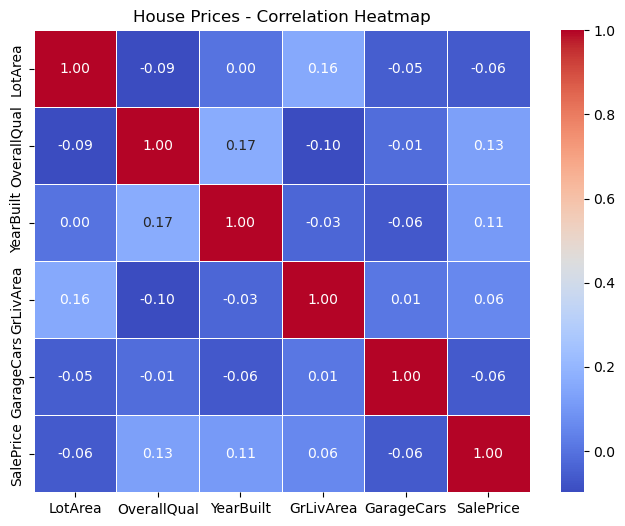

--- Top Features Affecting SalePrice ---
OverallQual    0.125395
YearBuilt      0.108181
GrLivArea      0.059644
GarageCars    -0.062654
LotArea       -0.062948
Name: SalePrice, dtype: float64


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- STEP 1: SAFE DUMMY DATA ---
np.random.seed(42)
n_samples = 200

data = {
    'LotArea': np.random.randint(5000, 15000, n_samples).astype(float),
    'OverallQual': np.random.randint(1, 10, n_samples).astype(float),
    'YearBuilt': np.random.randint(1950, 2020, n_samples).astype(float),
    'GrLivArea': np.random.randint(800, 3000, n_samples).astype(float),
    'GarageCars': np.random.choice([0, 1, 2, 3], n_samples).astype(float),
    'MSZoning': np.random.choice(['RL', 'RM', 'FV', 'C (all)'], n_samples),
    'CentralAir': np.random.choice(['Y', 'N'], n_samples),
    'SalePrice': np.random.randint(100000, 400000, n_samples).astype(float)
}

df = pd.DataFrame(data)

# Missing values daalna
df.loc[df.sample(frac=0.05).index, 'LotArea'] = np.nan
df.loc[df.sample(frac=0.05).index, 'MSZoning'] = np.nan

# --- STEP 2: FEATURES & TARGET ---
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

num_cols = ['LotArea', 'OverallQual', 'YearBuilt', 'GrLivArea', 'GarageCars']
cat_cols = ['MSZoning', 'CentralAir']

# --- STEP 3: VERSION-SAFE PIPELINE ---
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# sparse=False aur sparse_output=False dono ke jhanjhat se bachne ke liye 
# hum simple OneHotEncoder rakh rahe hain aur bad me array me convert karenge
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# --- STEP 4: SPLIT & TRANSFORM ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Agar output sparse matrix hai toh use normal array me badlo safely
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("--- 1. Preprocessing Pipeline Successful! ---")
print(f"Processed X_train shape: {X_train_processed.shape}\n")


# --- STEP 5: CORRELATION HEATMAP & TOP FEATURES ---
print("--- 2. Plotting Heatmap... ---")
plt.figure(figsize=(8, 6))

# Sirf numeric columns select karna
numeric_df = df[num_cols + ['SalePrice']]
corr_matrix = numeric_df.corr()

# Heatmap plot
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("House Prices - Correlation Heatmap")
plt.show()

# Top 5 features (ya jitne available hain) sorted order me
top_features = corr_matrix['SalePrice'].sort_values(ascending=False).iloc[1:]
print("--- Top Features Affecting SalePrice ---")
print(top_features)